Enter x1: 2
Enter y1: 3
Enter x2: 10
Enter y2: 8

Bresenham Algorithm (Slope < 1)
--------------------------------

Pixel Calculation Table:


,Step,Current X,Current Y,Decision Parameter,Selected Pixel,Next X,Next Y,Next Decision
0,1,2,3,2,NE Pixel,3,4,-4
1,2,3,4,-4,E Pixel,4,4,6
2,3,4,4,6,NE Pixel,5,5,0
3,4,5,5,0,NE Pixel,6,6,-6
4,5,6,6,-6,E Pixel,7,6,4
5,6,7,6,4,NE Pixel,8,7,-2
6,7,8,7,-2,E Pixel,9,7,8
7,8,9,7,8,NE Pixel,10,8,2



Generated Pixels:
[(2, 3), (3, 4), (4, 4), (5, 5), (6, 6), (7, 6), (8, 7), (9, 7), (10, 8)]


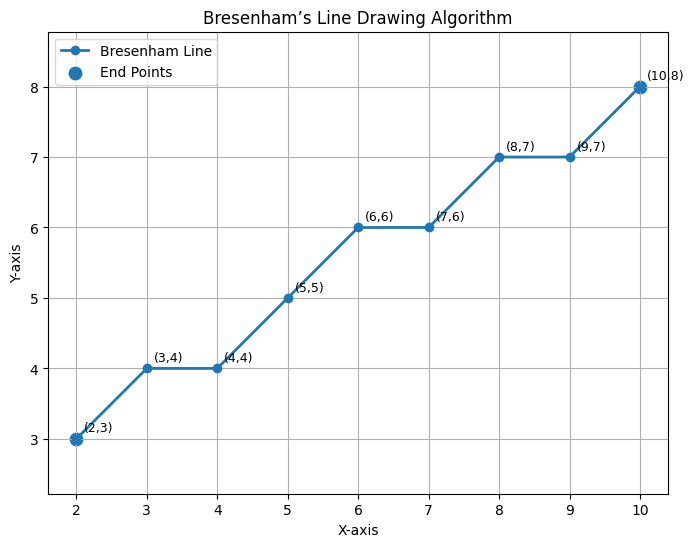

In [1]:

import matplotlib.pyplot as plt
import pandas as pd


def bresenham_line(x1, y1, x2, y2):

    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    x_step = 1 if x2 > x1 else -1
    y_step = 1 if y2 > y1 else -1


    if dx > dy:
        decision = 2 * dy - dx
    else:
        decision = 2 * dx - dy


    x = x1
    y = y1

    pixels = [(x, y)]
    table = []


    # Case 1: Slope < 1
    if dx > dy:

        print("\nBresenham Algorithm (Slope < 1)")
        print("--------------------------------")

        for i in range(dx):

            old_x = x
            old_y = y
            old_decision = decision


            if decision < 0:
                x = x + x_step
                decision = decision + 2 * dy
                choice = "E Pixel"

            else:
                x = x + x_step
                y = y + y_step
                decision = decision + 2 * dy - 2 * dx
                choice = "NE Pixel"


            pixels.append((x, y))


            table.append([
                i+1,
                old_x,
                old_y,
                old_decision,
                choice,
                x,
                y,
                decision
            ])


    # Case 2: Slope > 1
    else:

        print("\nBresenham Algorithm (Slope > 1)")
        print("--------------------------------")


        for i in range(dy):

            old_x = x
            old_y = y
            old_decision = decision


            if decision < 0:

                y = y + y_step
                decision = decision + 2 * dx
                choice = "N Pixel"


            else:

                x = x + x_step
                y = y + y_step
                decision = decision + 2 * dx - 2 * dy
                choice = "NE Pixel"


            pixels.append((x, y))


            table.append([
                i+1,
                old_x,
                old_y,
                old_decision,
                choice,
                x,
                y,
                decision
            ])



    # Display calculation table
    result = pd.DataFrame(
        table,
        columns=[
            "Step",
            "Current X",
            "Current Y",
            "Decision Parameter",
            "Selected Pixel",
            "Next X",
            "Next Y",
            "Next Decision"
        ]
    )


    print("\nPixel Calculation Table:")
    display(result)


    print("\nGenerated Pixels:")
    print(pixels)



    # Extract coordinates
    x_values = [p[0] for p in pixels]
    y_values = [p[1] for p in pixels]


    # Plot rasterized line
    plt.figure(figsize=(8,6))


    plt.plot(
        x_values,
        y_values,
        marker='o',
        linewidth=2,
        label="Bresenham Line"
    )


    # Display pixel coordinates
    for x, y in pixels:
        plt.text(
            x+0.1,
            y+0.1,
            f"({x},{y})",
            fontsize=9
        )


    plt.scatter(
        [x1, x2],
        [y1, y2],
        s=80,
        label="End Points"
    )


    plt.title("Bresenham’s Line Drawing Algorithm")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")

    plt.xticks(
        range(min(x_values)-1, max(x_values)+2)
    )

    plt.yticks(
        range(min(y_values)-1, max(y_values)+2)
    )

    plt.grid(True)
    plt.legend()
    plt.axis("equal")

    plt.show()




x1 = int(input("Enter x1: "))
y1 = int(input("Enter y1: "))

x2 = int(input("Enter x2: "))
y2 = int(input("Enter y2: "))


# Run Algorithm
bresenham_line(x1, y1, x2, y2)